In [21]:
from poseidon import poseidon  # 打包时注意
import pandas as pd
from functools import partial  # 偏函数，用于map传递多个参数
from multiprocessing import Pool  # 计算密集型采用该并行
import numpy as np
from sklearn.neighbors import LocalOutlierFactor
from itertools import product
import utils.time_util as time_util
from datetime import timedelta
from configs import config
import logging
from configs.config import AccessKey, SecretKey, GW_Url, OrgId
import asyncio
from concurrent.futures import ThreadPoolExecutor
from configs.config import Wind_Farm, EXCEPT_MODLES



Url_asset = GW_Url + '/cds-asset-service/v1.0/hierarchy?orgId=' + OrgId  # 这个api哪里来的？
Url_ai_normalized = GW_Url + '/tsdb-service/v2.1/ai-normalized?orgId=' + OrgId
Url_ai = GW_Url + '/tsdb-service/v2.1/ai?orgId=' + OrgId
Url_raw = GW_Url + '/tsdb-service/v2.1/raw?orgId=' + OrgId
Url_di = GW_Url + '/tsdb-service/v2.1/di?orgId=' + OrgId
Url_node = GW_Url + '/asset-tree-service/v2.1/asset-nodes?action=searchRelatedAsset&orgId=' + OrgId


def getWindTurbines(wind_farm):
    '''
    获取风场下的风机
    '''
    url_asset = Url_asset + '&mdmIds=' + wind_farm + \
        '&mdmTypes=EnOS_Wind_Turbine&attributes=mdmId,name,ratedPower'
    # with ThreadPoolExecutor(max_workers=3) as executor:
    #获取每一个风机属性
    ResponsePoint = poseidon.urlopen(AccessKey, SecretKey, url_asset)
    print(ResponsePoint['data'])

def getWindTurbinesNode(turbineIds, modelId):
    '''
    获取风场下的风机
    '''
    url_node = Url_node + '&treeId=VsKgAT9I' #+ \
        #'&projection=attributes,assetId,name'
    # with ThreadPoolExecutor(max_workers=3) as executor:
    params = {
        "filter": {
            "isChildOfAssetId": "IY2BuUEV"
        },
        "action": "searchRelatedAsset"
    }
    #获取每一个风机属性
    ResponsePoint = poseidon.urlopen(AccessKey, SecretKey, url_node, params)
    print(url_node)
    print(ResponsePoint)

getWindTurbines(Wind_Farm)
getWindTurbinesNode(Wind_Farm)

<urlopen error TLS/SSL connection has been closed (EOF) (_ssl.c:1135)>


TypeError: 'NoneType' object is not subscriptable

<Axes: xlabel='Month'>

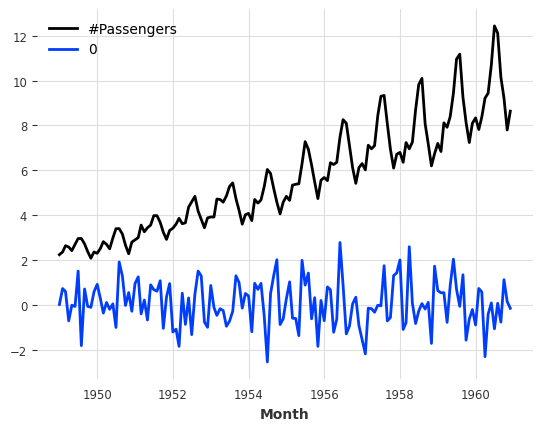

In [1]:
%matplotlib inline

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from darts import TimeSeries
from darts.datasets import AirPassengersDataset

series = AirPassengersDataset().load()
# series.plot()
# series1, series2 = series.split_after(0.75)
# series1.plot()
# series2.plot()

series_noise = TimeSeries.from_times_and_values(
    series.time_index, np.random.randn(len(series))
)
# (series / 2 + 20 * series_noise - 10).plot()
(series / 50).stack(series_noise).plot()

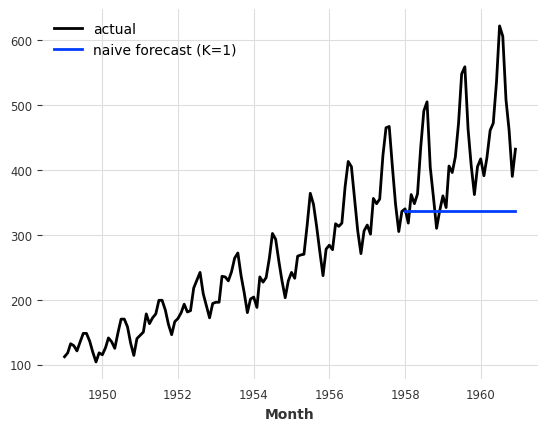

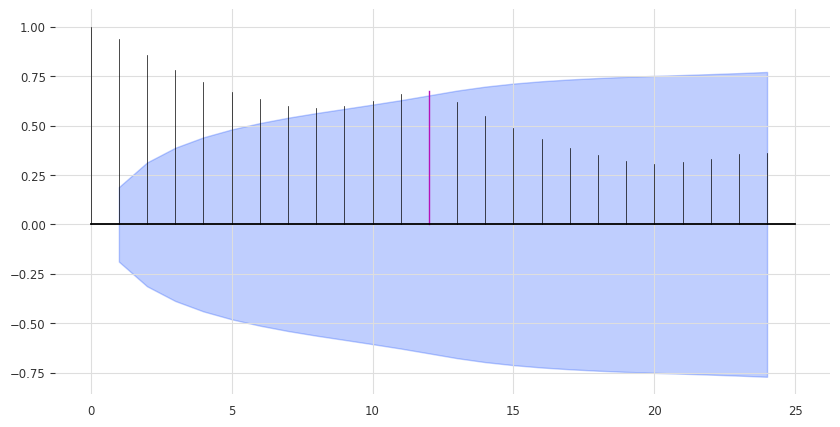

In [2]:
%matplotlib inline
from darts.models import NaiveSeasonal
from darts import TimeSeries
from darts.datasets import AirPassengersDataset
import pandas as pd
from darts.utils.statistics import plot_acf, check_seasonality


series = AirPassengersDataset().load()

train, val = series.split_before(pd.Timestamp("19580101"))
# train.plot(label="training")
# val.plot(label="validation")

naive_model = NaiveSeasonal(K=1)
naive_model.fit(train)
naive_forecast = naive_model.predict(36)

series.plot(label="actual")
naive_forecast.plot(label="naive forecast (K=1)")

plot_acf(train, m=12, alpha=0.05)

<Axes: xlabel='Month'>

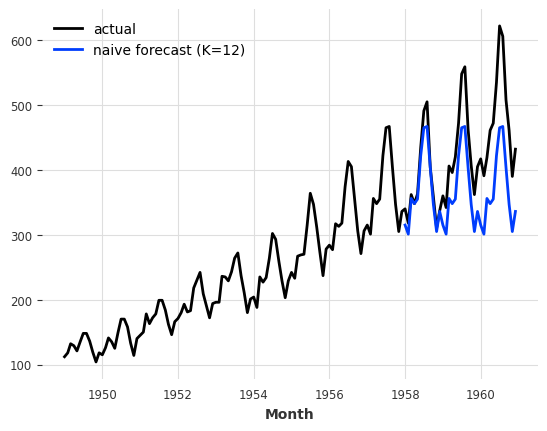

In [3]:
%matplotlib inline
from darts.models import NaiveSeasonal
from darts import TimeSeries
from darts.datasets import AirPassengersDataset
import pandas as pd
from darts.utils.statistics import plot_acf, check_seasonality


series = AirPassengersDataset().load()

train, val = series.split_before(pd.Timestamp("19580101"))
# train.plot(label="training")
# val.plot(label="validation")

seasonal_model = NaiveSeasonal(K=12)
seasonal_model.fit(train)
seasonal_forecast = seasonal_model.predict(36)

series.plot(label="actual")
seasonal_forecast.plot(label="naive forecast (K=12)")

<Axes: xlabel='Month'>

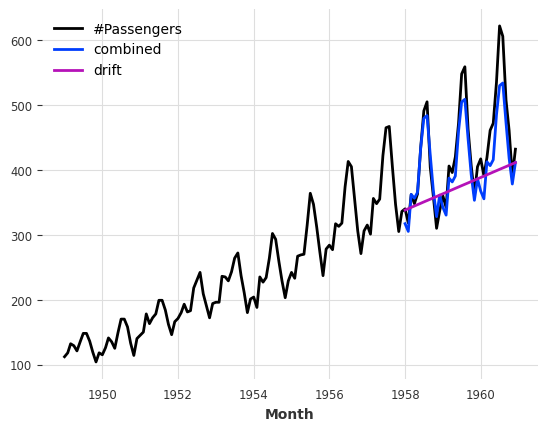

In [4]:
from darts.models import NaiveDrift

drift_model = NaiveDrift()
drift_model.fit(train)
drift_forecast = drift_model.predict(36)

combined_forecast = drift_forecast + seasonal_forecast - train.last_value()

series.plot()
combined_forecast.plot(label="combined")
drift_forecast.plot(label="drift")

In [5]:
from darts.metrics import mape

print(
    "Mean absolute percentage error for the combined naive drift + seasonal: {:.2f}%.".format(
        mape(series, combined_forecast)
    )
)

Mean absolute percentage error for the combined naive drift + seasonal: 5.66%.


In [6]:
from darts.models import ExponentialSmoothing, TBATS, AutoARIMA, Theta


def eval_model(model):
    model.fit(train)
    forecast = model.predict(len(val))
    print("model {} obtains MAPE: {:.2f}%".format(model, mape(val, forecast)))


eval_model(ExponentialSmoothing())
eval_model(TBATS())
eval_model(AutoARIMA())
eval_model(Theta())

model ExponentialSmoothing() obtains MAPE: 5.11%
model TBATS() obtains MAPE: 5.87%
model AutoARIMA() obtains MAPE: 11.65%
model Theta() obtains MAPE: 8.15%


The MAPE is: 4.40, with theta = -3.5102040816326543.


<Axes: xlabel='Month'>

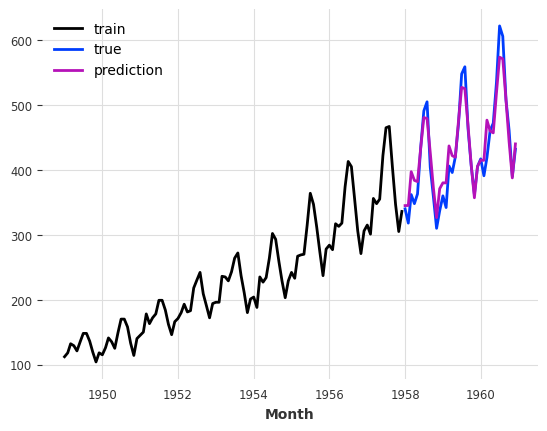

In [7]:
import numpy as np
# Search for the best theta parameter, by trying 50 different values
thetas = 2 - np.linspace(-10, 10, 50)

best_mape = float("inf")
best_theta = 0

for theta in thetas:
    model = Theta(theta)
    model.fit(train)
    pred_theta = model.predict(len(val))
    res = mape(val, pred_theta)

    if res < best_mape:
        best_mape = res
        best_theta = theta
best_theta_model = Theta(best_theta)
best_theta_model.fit(train)
pred_best_theta = best_theta_model.predict(len(val))

print(
    "The MAPE is: {:.2f}, with theta = {}.".format(
        mape(val, pred_best_theta), best_theta
    )
)

train.plot(label="train")
val.plot(label="true")
pred_best_theta.plot(label="prediction")

  0%|          | 0/25 [00:00<?, ?it/s]

MAPE = 4.60%


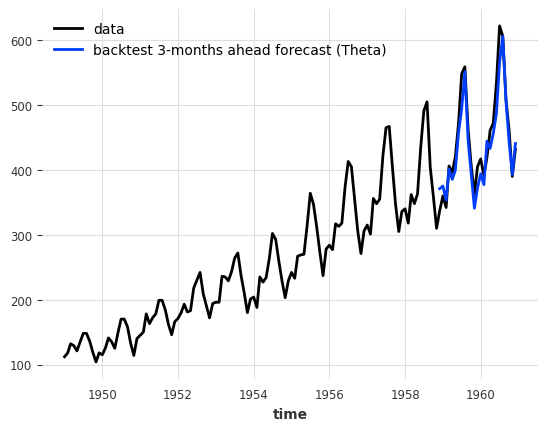

In [8]:
historical_fcast_theta = best_theta_model.historical_forecasts(
    series, start=train.end_time()+train.freq, forecast_horizon=12, verbose=True, stride=1
)

series.plot(label="data")
historical_fcast_theta.plot(label="backtest 3-months ahead forecast (Theta)")
print("MAPE = {:.2f}%".format(mape(historical_fcast_theta, series)))

  0%|          | 0/57 [00:00<?, ?it/s]

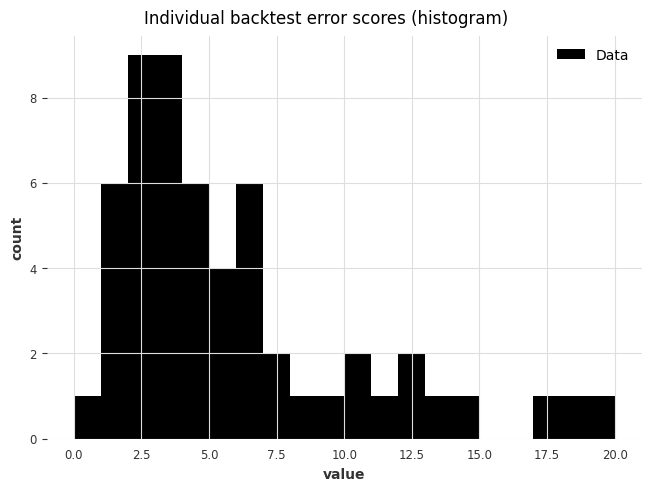

In [9]:
best_theta_model = Theta(best_theta)

raw_errors = best_theta_model.backtest(
    series, start=0.6, forecast_horizon=3, metric=mape, reduction=None, verbose=True
)

from darts.utils.statistics import plot_hist

plot_hist(
    raw_errors,
    bins=np.arange(0, max(raw_errors), 1),
    title="Individual backtest error scores (histogram)",
)

In [10]:
average_error = best_theta_model.backtest(
    series,
    start=0.6,
    forecast_horizon=3,
    metric=mape,
    reduction=np.mean,  # this is actually the default
    verbose=True,
)

print("Average error (MAPE) over all historical forecasts: %.2f" % average_error)

  0%|          | 0/57 [00:00<?, ?it/s]

Average error (MAPE) over all historical forecasts: 6.36


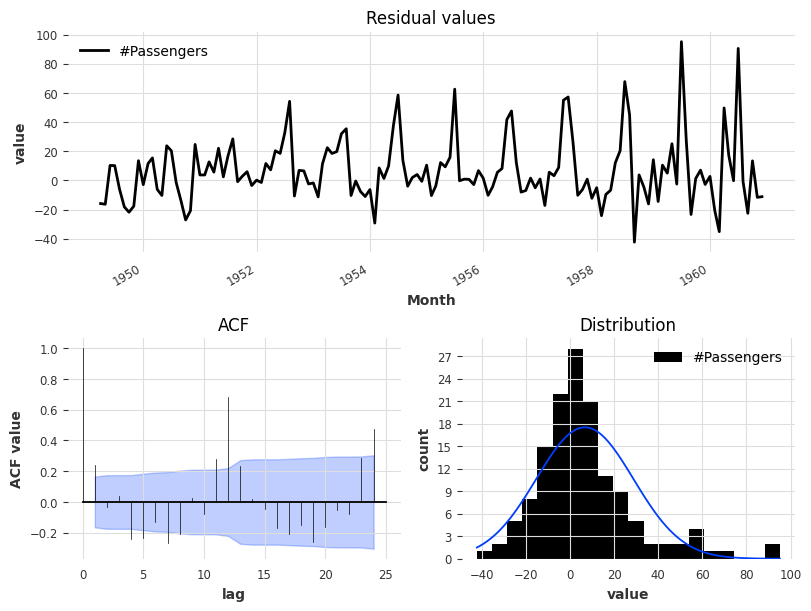

In [25]:
from darts.utils.statistics import plot_residuals_analysis

plot_residuals_analysis(best_theta_model.residuals(series))

  0%|          | 0/57 [00:00<?, ?it/s]

MAPE = 4.45%


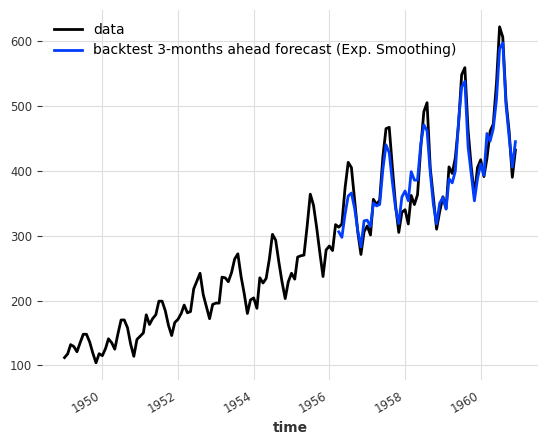

In [26]:
model_es = ExponentialSmoothing(seasonal_periods=12)
historical_fcast_es = model_es.historical_forecasts(
    series, start=0.6, forecast_horizon=3, verbose=True
)

series.plot(label="data")
historical_fcast_es.plot(label="backtest 3-months ahead forecast (Exp. Smoothing)")
print("MAPE = {:.2f}%".format(mape(historical_fcast_es, series)))

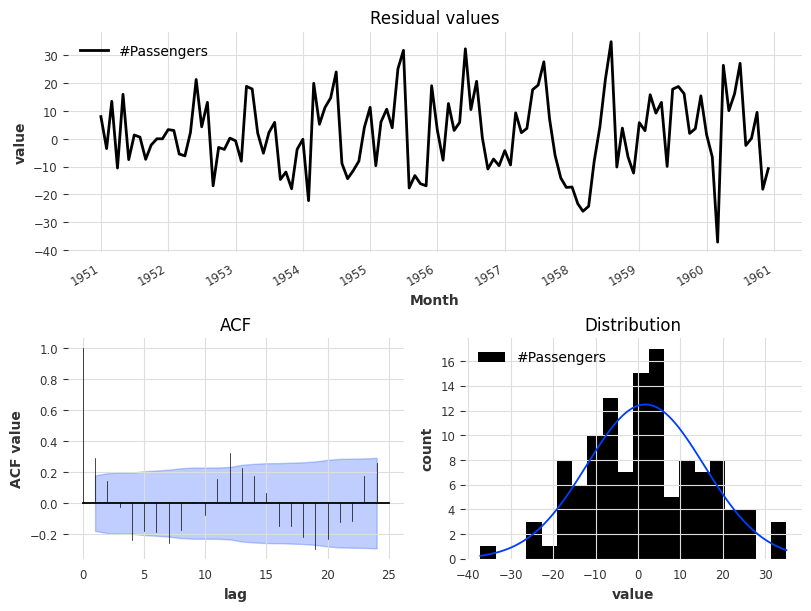

In [28]:
plot_residuals_analysis(model_es.residuals(series))

<Axes: xlabel='Month'>

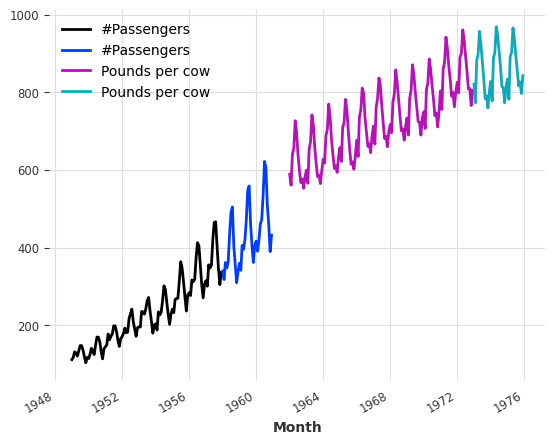

In [29]:
from darts.datasets import AirPassengersDataset, MonthlyMilkDataset
import numpy as np
%matplotlib inline

series_air = AirPassengersDataset().load().astype(np.float32)
series_milk = MonthlyMilkDataset().load().astype(np.float32)

# set aside last 36 months of each series as validation set:
train_air, val_air = series_air[:-36], series_air[-36:]
train_milk, val_milk = series_milk[:-36], series_milk[-36:]

train_air.plot()
val_air.plot()
train_milk.plot()
val_milk.plot()

<Axes: xlabel='Month'>

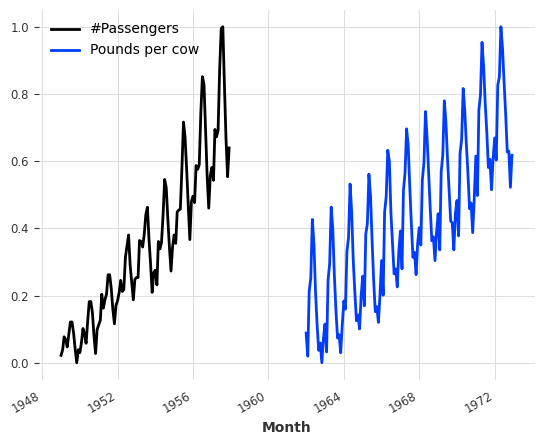

In [30]:
from darts.dataprocessing.transformers import Scaler

scaler = Scaler()
train_air_scaled, train_milk_scaled = scaler.fit_transform([train_air, train_milk])

train_air_scaled.plot()
train_milk_scaled.plot()

In [31]:
from darts.models import NBEATSModel

model = NBEATSModel(input_chunk_length=24, output_chunk_length=12, random_state=42)

model.fit([train_air_scaled, train_milk_scaled], epochs=50, verbose=True)



GPU available: False, used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs

  | Name          | Type             | Params
---------------------------------------------------
0 | criterion     | MSELoss          | 0     
1 | train_metrics | MetricCollection | 0     
2 | val_metrics   | MetricCollection | 0     
3 | stacks        | ModuleList       | 6.2 M 
---------------------------------------------------
6.2 M     Trainable params
1.4 K     Non-trainable params
6.2 M     Total params
24.787    Total estimated model params size (MB)


Training: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=50` reached.


NBEATSModel(output_chunk_shift=0, generic_architecture=True, num_stacks=30, num_blocks=1, num_layers=4, layer_widths=256, expansion_coefficient_dim=5, trend_polynomial_degree=2, dropout=0.0, activation=ReLU, input_chunk_length=24, output_chunk_length=12, random_state=42)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs


Predicting: |          | 0/? [00:00<?, ?it/s]

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs


Predicting: |          | 0/? [00:00<?, ?it/s]

<Axes: xlabel='Month'>

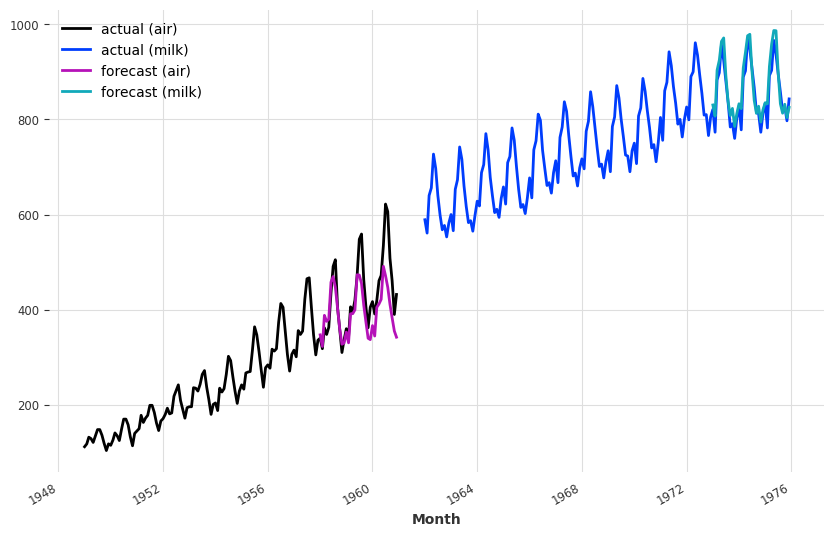

In [32]:
from matplotlib import pyplot as plt
pred_air = model.predict(series=train_air_scaled, n=36)
pred_milk = model.predict(series=train_milk_scaled, n=36)
# pred_air, pred_milk = model.predict(
#     series=[train_air_scaled, train_milk_scaled],
#     future_covariates=[air_covs, milk_covs],
#     n=36,
# )

# scale back:
pred_air, pred_milk = scaler.inverse_transform([pred_air, pred_milk])

plt.figure(figsize=(10, 6))
series_air.plot(label="actual (air)")
series_milk.plot(label="actual (milk)")
pred_air.plot(label="forecast (air)")
pred_milk.plot(label="forecast (milk)")

Text(0.5, 1.0, 'one multivariate time series of 2 dimensions, containing covariates for the air series:')

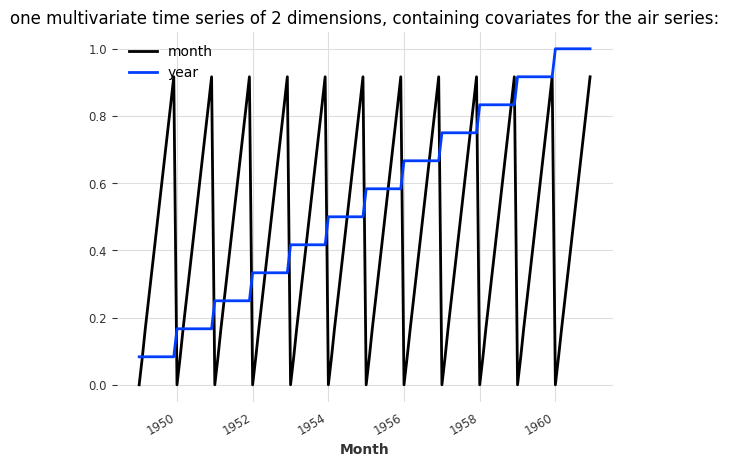

In [33]:
from darts import concatenate
from darts.utils.timeseries_generation import datetime_attribute_timeseries as dt_attr

air_covs = concatenate(
    [
        dt_attr(series_air.time_index, "month", dtype=np.float32) / 12,
        (dt_attr(series_air.time_index, "year", dtype=np.float32) - 1948) / 12,
    ],
    axis="component",
)

milk_covs = concatenate(
    [
        dt_attr(series_milk.time_index, "month", dtype=np.float32) / 12,
        (dt_attr(series_milk.time_index, "year", dtype=np.float32) - 1962) / 13,
    ],
    axis="component",
)

air_covs.plot()
plt.title(
    "one multivariate time series of 2 dimensions, containing covariates for the air series:"
)

Text(0.5, 1.0, 'one multivariate time series of 2 dimensions, containing covariates for the milk series:')

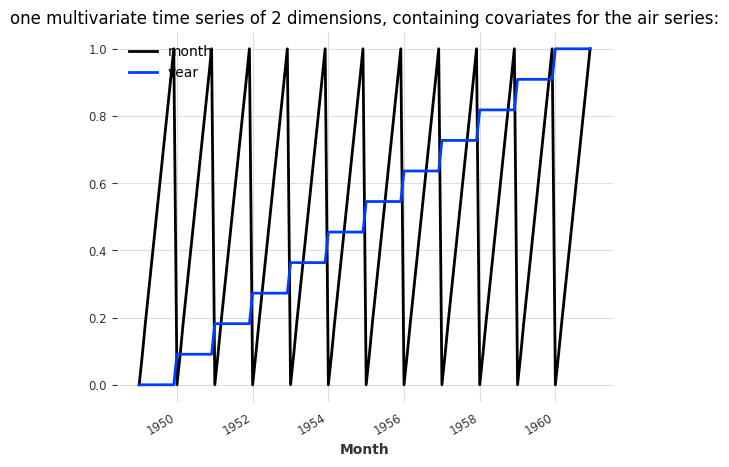

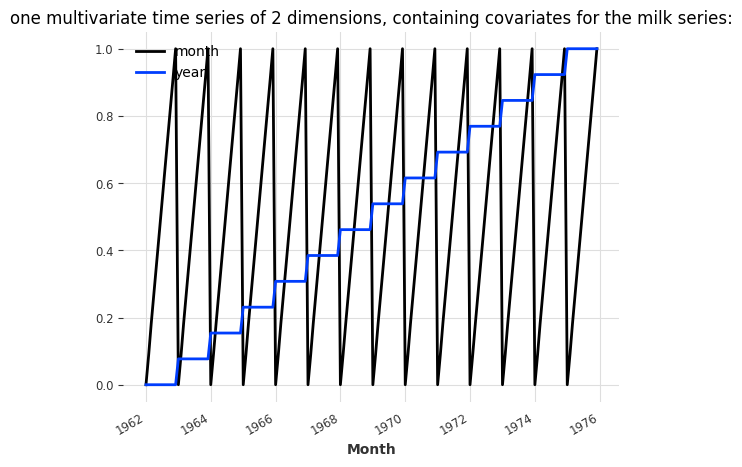

In [34]:
scaler_time = Scaler()

# train_air_scaled, train_milk_scaled = scaler.fit_transform([train_air, train_milk])

air_covs_ = concatenate(
    [
        scaler_time.fit_transform(dt_attr(series_air.time_index, "month", dtype=np.float32)),
        scaler_time.fit_transform(dt_attr(series_air.time_index, "year", dtype=np.float32)),
    ],
    axis="component",
)

milk_covs_ = concatenate(
    [
        # scaler_time.fit_transform([dt_attr(series_milk.time_index, "month", dtype=np.float32),dt_attr(series_milk.time_index, "year", dtype=np.float32)]), 报错
        scaler_time.fit_transform(dt_attr(series_milk.time_index, "month", dtype=np.float32)),
        scaler_time.fit_transform(dt_attr(series_milk.time_index, "year", dtype=np.float32)),
    ],
    axis="component",
)
plt.figure()
air_covs_.plot()
plt.title(
    "one multivariate time series of 2 dimensions, containing covariates for the air series:"
)
plt.figure()
milk_covs_.plot()
plt.title(
    "one multivariate time series of 2 dimensions, containing covariates for the milk series:"
)

In [35]:
model = NBEATSModel(input_chunk_length=24, output_chunk_length=12, random_state=42)

model.fit(
    [train_air_scaled, train_milk_scaled],
    past_covariates=[air_covs, milk_covs],
    epochs=50,
    verbose=True,
)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs

  | Name          | Type             | Params
---------------------------------------------------
0 | criterion     | MSELoss          | 0     
1 | train_metrics | MetricCollection | 0     
2 | val_metrics   | MetricCollection | 0     
3 | stacks        | ModuleList       | 6.6 M 
---------------------------------------------------
6.6 M     Trainable params
1.7 K     Non-trainable params
6.6 M     Total params
26.314    Total estimated model params size (MB)


Training: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=50` reached.


NBEATSModel(output_chunk_shift=0, generic_architecture=True, num_stacks=30, num_blocks=1, num_layers=4, layer_widths=256, expansion_coefficient_dim=5, trend_polynomial_degree=2, dropout=0.0, activation=ReLU, input_chunk_length=24, output_chunk_length=12, random_state=42)

`predict()` was called with `n > output_chunk_length`: using auto-regression to forecast the values after `output_chunk_length` points. The model will access `(n - output_chunk_length)` future values of your `past_covariates` (relative to the first predicted time step). To hide this warning, set `show_warnings=False`.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs


Predicting: |          | 0/? [00:00<?, ?it/s]

`predict()` was called with `n > output_chunk_length`: using auto-regression to forecast the values after `output_chunk_length` points. The model will access `(n - output_chunk_length)` future values of your `past_covariates` (relative to the first predicted time step). To hide this warning, set `show_warnings=False`.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs


Predicting: |          | 0/? [00:00<?, ?it/s]

<Axes: xlabel='Month'>

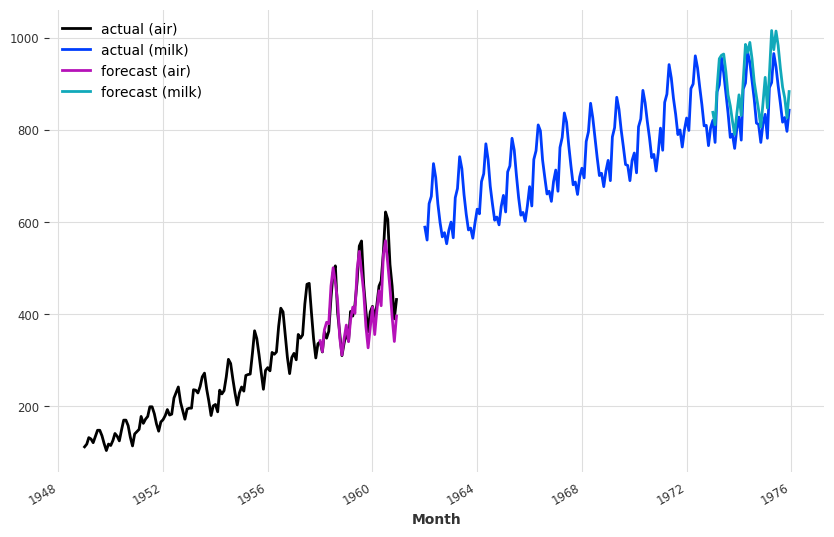

In [36]:
pred_air = model.predict(series=train_air_scaled, past_covariates=air_covs, n=36)
pred_milk = model.predict(series=train_milk_scaled, past_covariates=milk_covs, n=36)

# scale back:
pred_air, pred_milk = scaler.inverse_transform([pred_air, pred_milk])

plt.figure(figsize=(10, 6))
series_air.plot(label="actual (air)")
series_milk.plot(label="actual (milk)")
pred_air.plot(label="forecast (air)")
pred_milk.plot(label="forecast (milk)")

In [37]:
encoders = {"datetime_attribute": {"past": ["month", "year"]}, "transformer": Scaler()}#是用于外部些变量的放缩

model = NBEATSModel(
    input_chunk_length=24,
    output_chunk_length=12,
    add_encoders=encoders,
    random_state=42,
)

model.fit([train_air_scaled, train_milk_scaled], epochs=50, verbose=True)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs

  | Name          | Type             | Params
---------------------------------------------------
0 | criterion     | MSELoss          | 0     
1 | train_metrics | MetricCollection | 0     
2 | val_metrics   | MetricCollection | 0     
3 | stacks        | ModuleList       | 6.6 M 
---------------------------------------------------
6.6 M     Trainable params
1.7 K     Non-trainable params
6.6 M     Total params
26.314    Total estimated model params size (MB)


Training: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=50` reached.


NBEATSModel(output_chunk_shift=0, generic_architecture=True, num_stacks=30, num_blocks=1, num_layers=4, layer_widths=256, expansion_coefficient_dim=5, trend_polynomial_degree=2, dropout=0.0, activation=ReLU, input_chunk_length=24, output_chunk_length=12, add_encoders={'datetime_attribute': {'past': ['month', 'year']}, 'transformer': Scaler}, random_state=42)

`predict()` was called with `n > output_chunk_length`: using auto-regression to forecast the values after `output_chunk_length` points. The model will access `(n - output_chunk_length)` future values of your `past_covariates` (relative to the first predicted time step). To hide this warning, set `show_warnings=False`.


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs


Predicting: |          | 0/? [00:00<?, ?it/s]

<Axes: xlabel='Month'>

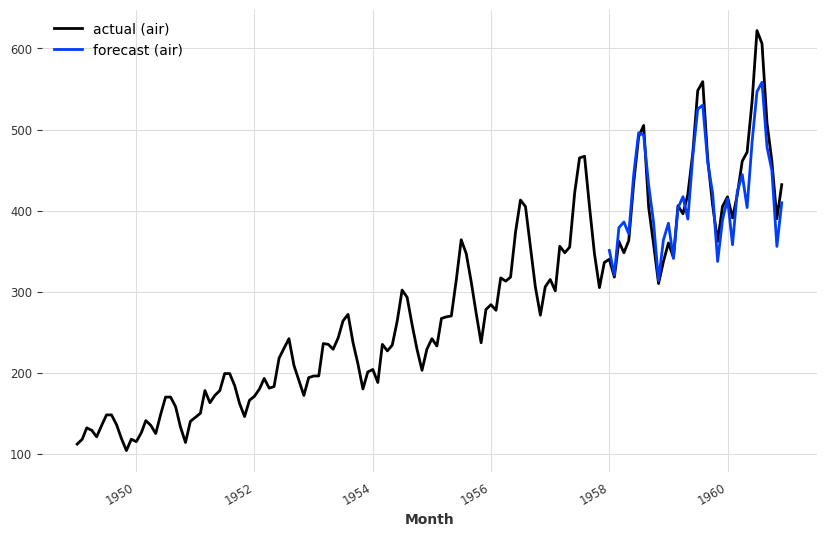

In [38]:
pred_air = model.predict(series=train_air_scaled, n=36)

# scale back:
pred_air = scaler.inverse_transform(pred_air)

plt.figure(figsize=(10, 6))
series_air.plot(label="actual (air)")
pred_air.plot(label="forecast (air)")

In [39]:
from darts.models import RegressionModel
from sklearn.linear_model import BayesianRidge

model = RegressionModel(lags=72, lags_future_covariates=[-6, 0], model=BayesianRidge())

model.fit(
    [train_air_scaled, train_milk_scaled], future_covariates=[air_covs, milk_covs]
)

RegressionModel(lags=72, lags_past_covariates=None, lags_future_covariates=[-6, 0], output_chunk_length=1, output_chunk_shift=0, add_encoders=None, model=BayesianRidge(), multi_models=True, use_static_covariates=True)

<Axes: xlabel='Month'>

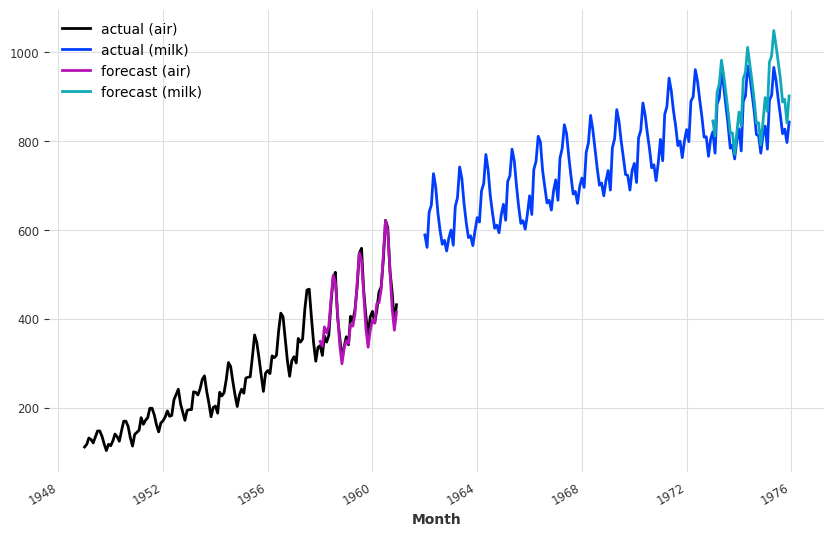

In [40]:
pred_air, pred_milk = model.predict(
    series=[train_air_scaled, train_milk_scaled],
    future_covariates=[air_covs, milk_covs],
    n=36,
)

# scale back:
pred_air, pred_milk = scaler.inverse_transform([pred_air, pred_milk])

plt.figure(figsize=(10, 6))
series_air.plot(label="actual (air)")
series_milk.plot(label="actual (milk)")
pred_air.plot(label="forecast (air)")
pred_milk.plot(label="forecast (milk)")

In [41]:
from darts.metrics import mape
mape([series_air, series_milk], [pred_air, pred_milk])

[3.4171126782894135, 5.28307668864727]

`enable_optimization=True` is ignored because `retrain` is not `False` or `0`.To hide this warning, set `show_warnings=False` or `enable_optimization=False`.
`enable_optimization=True` is ignored because `forecast_horizon > model.output_chunk_length`.To hide this warning, set `show_warnings=False` or `enable_optimization=False`.


  0%|          | 0/57 [00:00<?, ?it/s]

MAPE = 3.66


<Axes: xlabel='time'>

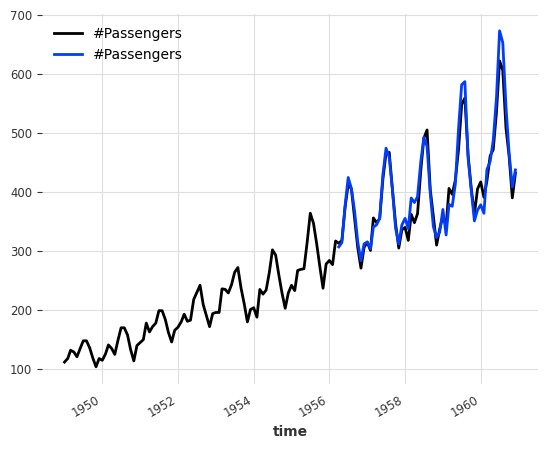

In [42]:
bayes_ridge_model = RegressionModel(
    lags=72, lags_future_covariates=[0], model=BayesianRidge()
)

backtest = bayes_ridge_model.historical_forecasts(
    series_air, future_covariates=air_covs, start=0.6, forecast_horizon=3, verbose=True
)

print("MAPE = %.2f" % (mape(backtest, series_air)))
series_air.plot()
backtest.plot()

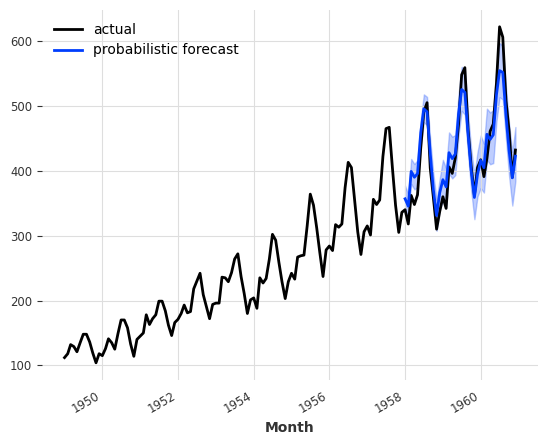

In [43]:
model_es = ExponentialSmoothing()
model_es.fit(train)
probabilistic_forecast = model_es.predict(len(val), num_samples=500)

series.plot(label="actual")
probabilistic_forecast.plot(label="probabilistic forecast")
plt.legend()
plt.show()

In [44]:
from darts.models import TCNModel
from darts.utils.likelihood_models import LaplaceLikelihood

model = TCNModel(
    input_chunk_length=24,
    output_chunk_length=12,
    random_state=42,
    likelihood=LaplaceLikelihood(),
)

model.fit(train_air_scaled, epochs=400, verbose=True)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs

  | Name          | Type              | Params
----------------------------------------------------
0 | criterion     | MSELoss           | 0     
1 | train_metrics | MetricCollection  | 0     
2 | val_metrics   | MetricCollection  | 0     
3 | dropout       | MonteCarloDropout | 0     
4 | res_blocks    | ModuleList        | 166   
----------------------------------------------------
166       Trainable params
0         Non-trainable params
166       Total params
0.001     Total estimated model params size (MB)


Training: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=400` reached.


TCNModel(output_chunk_shift=0, kernel_size=3, num_filters=3, num_layers=None, dilation_base=2, weight_norm=False, dropout=0.2, input_chunk_length=24, output_chunk_length=12, random_state=42, likelihood=LaplaceLikelihood(prior_mu=None, prior_b=None, prior_strength=1.0))

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs


Predicting: |          | 0/? [00:00<?, ?it/s]

<Axes: xlabel='Month'>

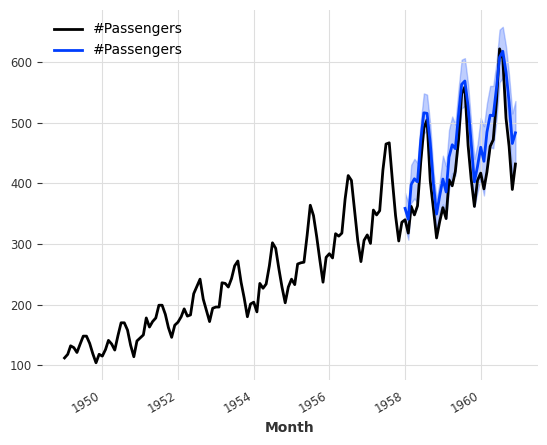

In [45]:
pred = model.predict(n=36, num_samples=500)

# scale back:
pred = scaler.inverse_transform(pred)

series_air.plot()
pred.plot()

In [46]:
model = TCNModel(
    input_chunk_length=24,
    output_chunk_length=12,
    random_state=42,
    likelihood=LaplaceLikelihood(prior_b=0.1),
)

model.fit(train_air_scaled, epochs=400, verbose=True)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs

  | Name          | Type              | Params
----------------------------------------------------
0 | criterion     | MSELoss           | 0     
1 | train_metrics | MetricCollection  | 0     
2 | val_metrics   | MetricCollection  | 0     
3 | dropout       | MonteCarloDropout | 0     
4 | res_blocks    | ModuleList        | 166   
----------------------------------------------------
166       Trainable params
0         Non-trainable params
166       Total params
0.001     Total estimated model params size (MB)


Training: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=400` reached.


TCNModel(output_chunk_shift=0, kernel_size=3, num_filters=3, num_layers=None, dilation_base=2, weight_norm=False, dropout=0.2, input_chunk_length=24, output_chunk_length=12, random_state=42, likelihood=LaplaceLikelihood(prior_mu=None, prior_b=None, prior_strength=1.0))

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs


Predicting: |          | 0/? [00:00<?, ?it/s]

<Axes: xlabel='Month'>

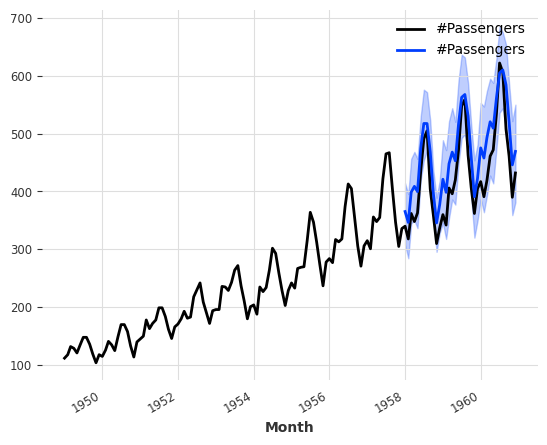

In [47]:
pred = model.predict(n=36, num_samples=500)

# scale back:
pred = scaler.inverse_transform(pred)

series_air.plot()
pred.plot()

<Axes: xlabel='Month'>

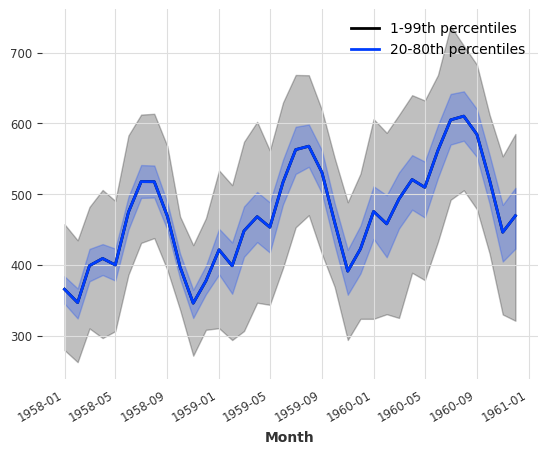

In [48]:
pred.plot(low_quantile=0.01, high_quantile=0.99, label="1-99th percentiles")
pred.plot(low_quantile=0.2, high_quantile=0.8, label="20-80th percentiles")

In [50]:
from darts.metrics import rho_risk

print("MAPE of median forecast: %.2f" % mape(series_air, pred))
for rho in [0.05, 0.1, 0.5, 0.9, 0.95]:
    rr = rho_risk(series_air, pred, rho=rho)
    print("rho-risk at quantile %.2f: %.2f" % (rho, rr))

MAPE of median forecast: 10.37
rho-risk at quantile 0.05: 0.11
rho-risk at quantile 0.10: 0.11
rho-risk at quantile 0.50: 0.09
rho-risk at quantile 0.90: 0.02
rho-risk at quantile 0.95: 0.01


In [51]:
from darts.utils.likelihood_models import QuantileRegression

model = TCNModel(
    input_chunk_length=24,
    output_chunk_length=12,
    random_state=42,
    likelihood=QuantileRegression([0.05, 0.1, 0.5, 0.9, 0.95]),
)

model.fit(train_air_scaled, epochs=400, verbose=True)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs

  | Name          | Type              | Params
----------------------------------------------------
0 | criterion     | MSELoss           | 0     
1 | train_metrics | MetricCollection  | 0     
2 | val_metrics   | MetricCollection  | 0     
3 | dropout       | MonteCarloDropout | 0     
4 | res_blocks    | ModuleList        | 208   
----------------------------------------------------
208       Trainable params
0         Non-trainable params
208       Total params
0.001     Total estimated model params size (MB)


Training: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=400` reached.


TCNModel(output_chunk_shift=0, kernel_size=3, num_filters=3, num_layers=None, dilation_base=2, weight_norm=False, dropout=0.2, input_chunk_length=24, output_chunk_length=12, random_state=42, likelihood=QuantileRegression(quantiles: Union[List[float], NoneType] = None))

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs


Predicting: |          | 0/? [00:00<?, ?it/s]

MAPE of median forecast: 7.89
rho-risk at quantile 0.05: 0.00
rho-risk at quantile 0.10: 0.00
rho-risk at quantile 0.50: 0.02
rho-risk at quantile 0.90: 0.01
rho-risk at quantile 0.95: 0.01


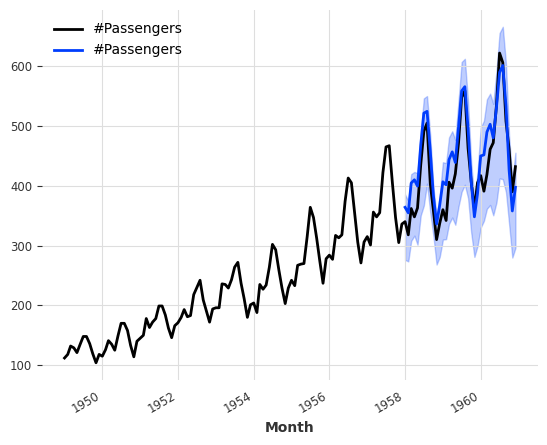

In [52]:
pred = model.predict(n=36, num_samples=500)

# scale back:
pred = scaler.inverse_transform(pred)

series_air.plot()
pred.plot()

print("MAPE of median forecast: %.2f" % mape(series_air, pred))
for rho in [0.05, 0.1, 0.5, 0.9, 0.95]:
    rr = rho_risk(series_air, pred, rho=rho)
    print("rho-risk at quantile %.2f: %.2f" % (rho, rr))

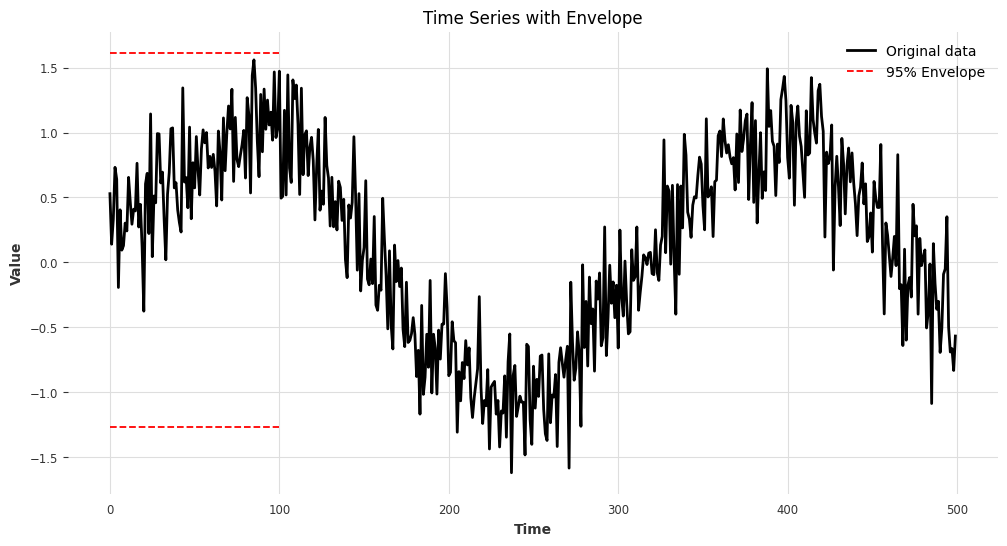

In [55]:
import matplotlib.pyplot as plt
from darts import TimeSeries
import numpy as np

# 生成一个正弦波时间序列并添加噪声
np.random.seed(0)
t = np.linspace(0, 100, 500)
y = np.sin(0.1 * t) + 0.3 * np.random.randn(500)

# 创建Darts的TimeSeries对象
time_series = TimeSeries.from_values(y)

# 计算平均值和标准差
mean = np.mean(y)
std = np.std(y)

# 计算95%的包络线
upper_envelope = mean + 1.96 * std
lower_envelope = mean - 1.96 * std

# 绘制时间序列数据的曲线以及其包络线
plt.figure(figsize=(12, 6))
time_series.plot(label='Original data')
plt.plot(t, [upper_envelope]*len(t), 'r--', label='95% Envelope')
plt.plot(t, [lower_envelope]*len(t), 'r--')
plt.title('Time Series with Envelope')
plt.xlabel('Time')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.show()

  0%|          | 0/57 [00:00<?, ?it/s]

MAPE = 11.88


<Axes: xlabel='time'>

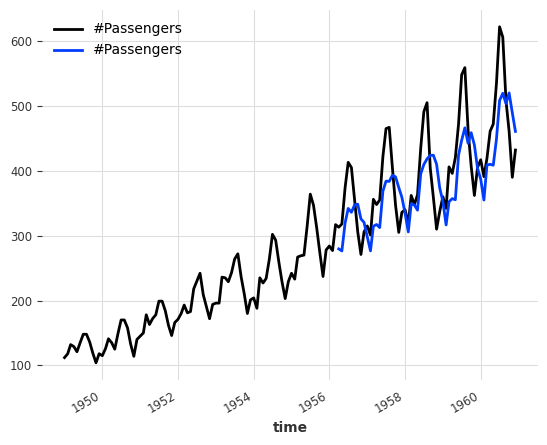

In [56]:
from darts.models import NaiveEnsembleModel

models = [NaiveDrift(), NaiveSeasonal(12)]

ensemble_model = NaiveEnsembleModel(forecasting_models=models)

backtest = ensemble_model.historical_forecasts(
    series_air, start=0.6, forecast_horizon=3, verbose=True
)

print("MAPE = %.2f" % (mape(backtest, series_air)))
series_air.plot()
backtest.plot()

  0%|          | 0/57 [00:00<?, ?it/s]

MAPE = 4.85


<Axes: xlabel='time'>

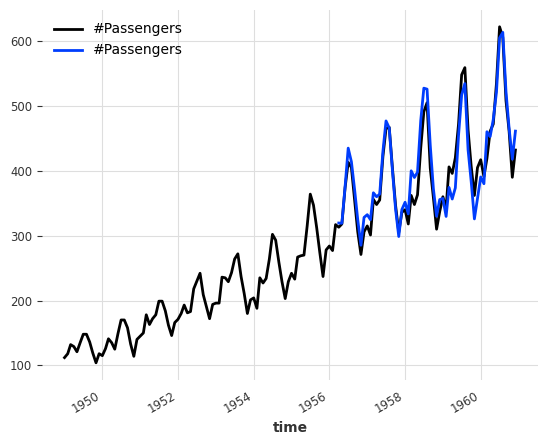

In [57]:
from darts.models import RegressionEnsembleModel

models = [NaiveDrift(), NaiveSeasonal(12)]

ensemble_model = RegressionEnsembleModel(
    forecasting_models=models, regression_train_n_points=12
)

backtest = ensemble_model.historical_forecasts(
    series_air, start=0.6, forecast_horizon=3, verbose=True
)

print("MAPE = %.2f" % (mape(backtest, series_air)))
series_air.plot()
backtest.plot()

In [58]:
ensemble_model.fit(series_air)
ensemble_model.regression_model.model.coef_

array([0.01368849, 1.0980105 ], dtype=float32)

  0%|          | 0/57 [00:00<?, ?it/s]

MAPE = 4.81


<Axes: xlabel='time'>

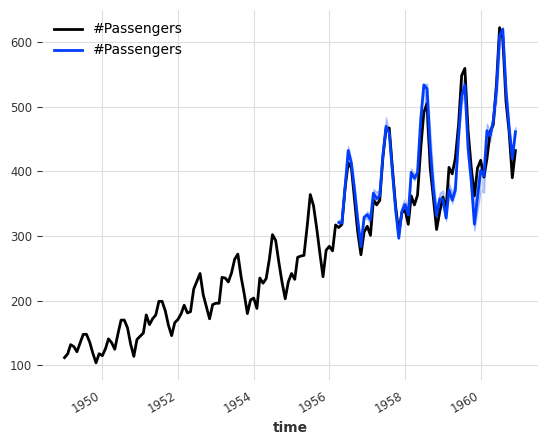

In [59]:
from darts.models import LinearRegressionModel

quantiles = [0.25, 0.5, 0.75]

models = [NaiveDrift(), NaiveSeasonal(12)]

regression_model = LinearRegressionModel(
    quantiles=quantiles,
    lags_future_covariates=[0],
    likelihood="quantile",
    fit_intercept=False,
)

ensemble_model = RegressionEnsembleModel(
    forecasting_models=models,
    regression_train_n_points=12,
    regression_model=regression_model,
)

backtest = ensemble_model.historical_forecasts(
    series_air, start=0.6, forecast_horizon=3, num_samples=500, verbose=True
)

print("MAPE = %.2f" % (mape(backtest, series_air)))
series_air.plot()
backtest.plot()

You are transforming a stochastic TimeSeries (i.e., contains several samples). The resulting DataFrame is a 2D object with all samples on the columns. If this is not the expected behavior consider calling a function adapted to stochastic TimeSeries like quantile_df().


<class 'darts.timeseries.TimeSeries'>
(108, 100)
(108, 1)
Index(['#Passengers'], dtype='object', name='component')


<Axes: xlabel='Month'>

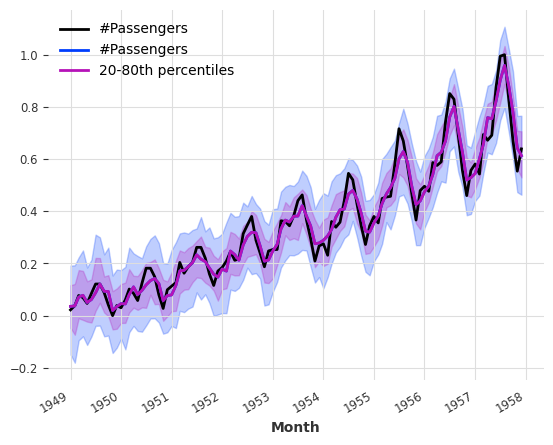

In [71]:
from darts.models import KalmanFilter

kf = KalmanFilter(dim_x=3)
kf.fit(train_air_scaled)
filtered_series = kf.filter(train_air_scaled, num_samples=100)

train_air_scaled.plot()
filtered_series.plot()
df_filter_series = filtered_series.pd_dataframe()
df_train_series = train_air_scaled.pd_dataframe()
print(type(filtered_series))
print(df_filter_series.shape)
print(df_train_series.shape)
print(df_train_series.columns)
filtered_series.plot(low_quantile=0.2, high_quantile=0.8, label="20-80th percentiles")

<Axes: xlabel='Month'>

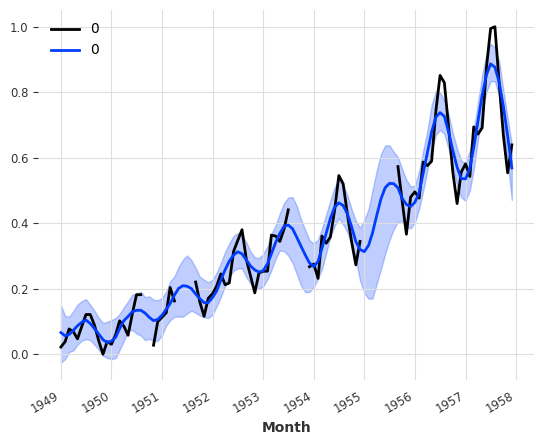

In [72]:
from darts.models import GaussianProcessFilter
from sklearn.gaussian_process.kernels import RBF

# create a series with holes:
values = train_air_scaled.values()
values[20:22] = np.nan
values[28:32] = np.nan
values[55:59] = np.nan
values[72:80] = np.nan
series_holes = TimeSeries.from_times_and_values(train_air_scaled.time_index, values)
series_holes.plot()

kernel = RBF()

gpf = GaussianProcessFilter(kernel=kernel, alpha=0.1, normalize_y=True)
filtered_series = gpf.filter(series_holes, num_samples=100)

filtered_series.plot()

# Temporal Fusion Transformer

In [30]:
#启用自动重载模块功能。
%load_ext autoreload
#自动重新加载所有导入的模块。
%autoreload 2
#在Notebook内部嵌入matplotlib图形。
%matplotlib inline 

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [31]:
import numpy as np
import pandas as pd
from tqdm import tqdm_notebook as tqdm

import matplotlib.pyplot as plt

from darts import TimeSeries, concatenate
from darts.dataprocessing.transformers import Scaler
from darts.models import TFTModel
from darts.metrics import mape
from darts.utils.statistics import check_seasonality, plot_acf
from darts.datasets import AirPassengersDataset, IceCreamHeaterDataset
from darts.utils.timeseries_generation import datetime_attribute_timeseries
from darts.utils.likelihood_models import QuantileRegression

import warnings

warnings.filterwarnings("ignore")
import logging

logging.disable(logging.CRITICAL)

In [32]:
# before starting, we define some constants
num_samples = 200

figsize = (9, 6)
lowest_q, low_q, high_q, highest_q = 0.01, 0.1, 0.9, 0.99
label_q_outer = f"{int(lowest_q * 100)}-{int(highest_q * 100)}th percentiles"
label_q_inner = f"{int(low_q * 100)}-{int(high_q * 100)}th percentiles"

In [34]:
# Read data
series = AirPassengersDataset().load() #timeseries类型

# we convert monthly number of passengers to average daily number of passengers per month
series = series / TimeSeries.from_series(series.time_index.days_in_month)
series = series.astype(np.float32)

# Create training and validation sets:
training_cutoff = pd.Timestamp("19571201")
train, val = series.split_after(training_cutoff)

# Normalize the time series (note: we avoid fitting the transformer on the validation set)
transformer = Scaler()
#在训练集上拟合一个归一化函数并对原值进行归一化转化
train_transformed = transformer.fit_transform(train)
#在测试集上用之前拟合好的归一化函数对原值进行归一化转化
val_transformed = transformer.transform(val)
series_transformed = transformer.transform(series)

# create year, month and integer index covariate series
covariates = datetime_attribute_timeseries(series, attribute="year", one_hot=False)
covariates = covariates.stack(
    datetime_attribute_timeseries(series, attribute="month", one_hot=False)
)
#from_times_and_values创建一个TimeSeries对象，通过时间索引和对应的值方式
covariates = covariates.stack(
    TimeSeries.from_times_and_values(
        times=series.time_index,
        values=np.arange(len(series)),
        columns=["linear_increase"],
    )
)
covariates = covariates.astype(np.float32)

# transform covariates (note: we fit the transformer on train split and can then transform the entire covariates series)
scaler_covs = Scaler()
cov_train, cov_val = covariates.split_after(training_cutoff)
#拟合一个归一化函数
scaler_covs.fit(cov_train)
#用拟合好的归一化
covariates_transformed = scaler_covs.transform(covariates)


In [12]:
# default quantiles for QuantileRegression
quantiles = [
    0.01,
    0.05,
    0.1,
    0.15,
    0.2,
    0.25,
    0.3,
    0.4,
    0.5,
    0.6,
    0.7,
    0.75,
    0.8,
    0.85,
    0.9,
    0.95,
    0.99,
]
input_chunk_length = 24
forecast_horizon = 12
my_model = TFTModel(
    input_chunk_length=input_chunk_length,
    output_chunk_length=forecast_horizon,
    hidden_size=64,
    lstm_layers=1,
    num_attention_heads=4,
    dropout=0.1,
    batch_size=16,
    n_epochs=300,
    add_relative_index=False,
    add_encoders=None,
    likelihood=QuantileRegression(
        quantiles=quantiles
    ),  # QuantileRegression is set per default
    # loss_fn=MSELoss(),
    random_state=42,
)

In [35]:
my_model.fit(train_transformed, future_covariates=covariates_transformed, verbose=True)


Training: |          | 0/? [00:00<?, ?it/s]

TFTModel(output_chunk_shift=0, hidden_size=64, lstm_layers=1, num_attention_heads=4, full_attention=False, feed_forward=GatedResidualNetwork, dropout=0.1, hidden_continuous_size=8, categorical_embedding_sizes=None, add_relative_index=False, loss_fn=None, likelihood=QuantileRegression(quantiles: Union[List[float], NoneType] = None), norm_type=LayerNorm, use_static_covariates=True, input_chunk_length=24, output_chunk_length=12, batch_size=16, n_epochs=300, add_encoders=None, random_state=42)

Predicting: |          | 0/? [00:00<?, ?it/s]

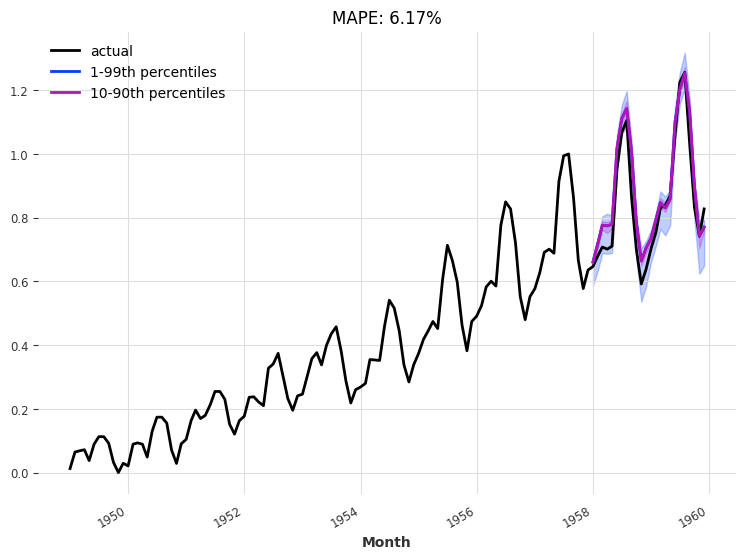

In [36]:
def eval_model(model, n, actual_series, val_series):
    pred_series = model.predict(n=n, num_samples=num_samples)

    # plot actual series
    plt.figure(figsize=figsize)
    actual_series[: pred_series.end_time()].plot(label="actual")

    # plot prediction with quantile ranges
    pred_series.plot(
        low_quantile=lowest_q, high_quantile=highest_q, label=label_q_outer
    )
    pred_series.plot(low_quantile=low_q, high_quantile=high_q, label=label_q_inner)

    plt.title("MAPE: {:.2f}%".format(mape(val_series, pred_series)))
    plt.legend()


eval_model(my_model, 24, series_transformed, val_transformed)

## 回溯测试

In [75]:
backtest_series = my_model.historical_forecasts(
    series_transformed,
    future_covariates=covariates_transformed,
    start=train.end_time() + train.freq,
    num_samples=num_samples,
    forecast_horizon=forecast_horizon,
    stride=forecast_horizon,
    last_points_only=False,
    retrain=False,
    verbose=True,
)
print(train.end_time())
print(len(train))
print(train.freq)


Predicting: |          | 0/? [00:00<?, ?it/s]

1957-12-01 00:00:00
108
<MonthBegin>


MAPE: 4.49%


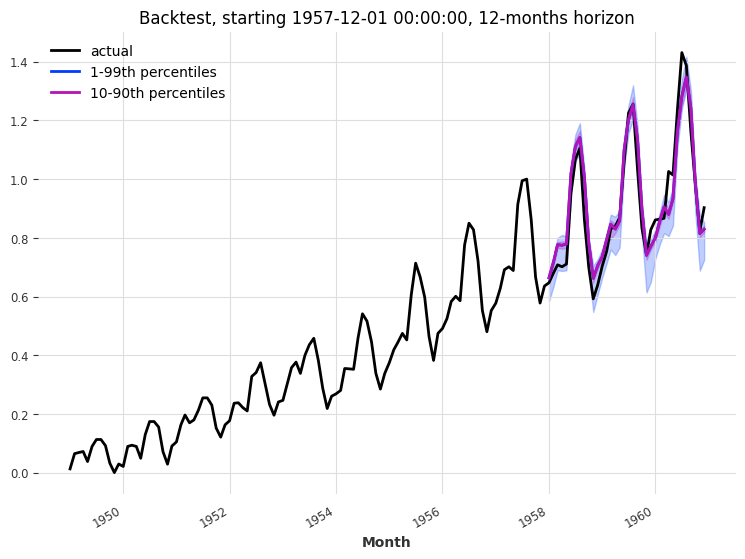

In [72]:
def eval_backtest(backtest_series, actual_series, horizon, start, transformer):
    plt.figure(figsize=figsize)
    actual_series.plot(label="actual")
    backtest_series.plot(
        low_quantile=lowest_q, high_quantile=highest_q, label=label_q_outer
    )
    backtest_series.plot(low_quantile=low_q, high_quantile=high_q, label=label_q_inner)
    plt.legend()
    plt.title(f"Backtest, starting {start}, {horizon}-months horizon")
    print(
        "MAPE: {:.2f}%".format(
            mape(
                transformer.inverse_transform(actual_series),
                transformer.inverse_transform(backtest_series),
            )
        )
    )


eval_backtest(
    backtest_series=concatenate(backtest_series,ignore_time_axis=True),
    actual_series=series_transformed,
    horizon=forecast_horizon,
    start=training_cutoff,
    transformer=transformer,
)

In [11]:
from darts import TimeSeries
# from darts.models import TFT
from darts.models import TFTModel as TFT
# from sklearn.preprocessing import StandardScaler
from darts.dataprocessing.transformers import Scaler
import numpy as np
import pandas as pd

# 创建一个示例时间序列数据
data1 = np.linspace(0, 10, 30)  # 第一条水平线
data2 = np.linspace(20, 30, 100)  # 第二条水平线
data = np.concatenate([data1, data2])
index = pd.date_range(start='2022-01-01', periods=len(data), freq='D')
series = pd.Series(data, index=index)
# series = series.truncate(before='2022-04-01', after='2022-05-01')
series = series[(series.index < pd.Timestamp('2022-04-1')) | (series.index > pd.Timestamp('2022-5-1'))]
series = TimeSeries.from_series(series, freq='D')
# series = TimeSeries.from_values(data)

# 数据标准化
scaler = Scaler()
# scaled_data = scaler.fit_transform(series.values().reshape(-1, 1)).flatten()
scaled_data = scaler.fit_transform(series)

# 创建标准化后的时间序列
# scaled_series = TimeSeries.from_series(scaled_data)

# scaled_series = TimeSeries.from_values(scaled_data)

# 初始化并训练TFT模型
model = TFT(input_chunk_length=20, output_chunk_length=10, n_epochs=10,add_encoders={ 
                    "cyclic": {"future": ["day", "week", "month"]},
                    "datetime_attribute":{"future": ["day", "week", "month"]}
                },
                add_relative_index=False, random_state=42)
model.fit([scaled_data], verbose=True)

# 获取训练损失
train_loss = model.history['train_loss']

print(f"Train loss: {train_loss}")


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs

   | Name                              | Type                             | Params
----------------------------------------------------------------------------------------
0  | train_metrics                     | MetricCollection                 | 0     
1  | val_metrics                       | MetricCollection                 | 0     
2  | input_embeddings                  | _MultiEmbedding                  | 0     
3  | static_covariates_vsn             | _VariableSelectionNetwork        | 0     
4  | encoder_vsn                       | _VariableSelectionNetwork        | 6.6 K 
5  | decoder_vsn                       | _VariableSelectionNetwork        | 5.9 K 
6  | static_context_grn                | _GatedResidualNetwork            | 1.1 K 
7  | static_context_hidden_encoder_grn | _GatedResidualNetwork            | 1.1 K 
8  | static_cont

Training: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=10` reached.
ERROR:tornado.general:SEND Error: Host unreachable


AttributeError: 'TFTModel' object has no attribute 'history'

In [12]:
import pandas as pd

# 创建示例数据
data = {'value': [1, 2, 3, 4, 5]}
index = pd.date_range(start='2024-01-17', end='2024-04-01', freq='10T')  # 10分钟频率
df = pd.DataFrame(data, index=index)
print(df)

ValueError: Length of values (5) does not match length of index (10801)

# A decorator for timing coroutines

In [5]:
import functools
import time
from typing import Callable, Any

def async_timed():
    def wrapper(func: Callable)->Callable:
        @functools.wraps(func)
        async def wrapped(*args, **kwargs)->Any:
            print(f'starting {func} with args {args} {kwargs}')
            start = time.time()
            try:
                return await func(*args, **kwargs)
            finally:
                end = time.time()
                total = end - start
                print(f"finished {func}  with args {args} {kwargs} in {total:.4f} second(s)")
        return wrapped
    return wrapper

## timing two concurrent tasks with a decorator

In [11]:
import asyncio

@async_timed()
async def  delay(delay_seconds: int)->int:
    print(f'theory sleeping for {delay_seconds} second(s)')
    await asyncio.sleep(delay_seconds)
    print(f'finished theory sleeping for {delay_seconds} second(s)')
    return delay_seconds

@async_timed()
async def main():
    task_one = asyncio.create_task(delay(2))
    task_two = asyncio.create_task(delay(10))

    # await task_two
    # await task_one

# asyncio.run(main(), debug=True)
task_main = asyncio.create_task(main())
# await asyncio.create_task(main())
# await task_main
print("main完成")

starting <function main at 0x1046fd5e0> with args () {}
finished <function main at 0x1046fd5e0>  with args () {} in 0.0000 second(s)
starting <function delay at 0x10470ea60> with args (2,) {}
theory sleeping for 2 second(s)
starting <function delay at 0x10470ea60> with args (10,) {}
theory sleeping for 10 second(s)
main完成


finished theory sleeping for 2 second(s)
finished <function delay at 0x10470ea60>  with args (2,) {} in 2.0012 second(s)
finished theory sleeping for 10 second(s)
finished <function delay at 0x10470ea60>  with args (10,) {} in 10.0018 second(s)


In [1]:
a = 'ABV000013'
n = ''.join([c for c in a if c.isdigit()])
print(n)
print(int(n))


000013
13


In [23]:
import pandas as pd

df1 = pd.DataFrame({
    'A': ['A0', 'A1', 'A2', 'A3'],
    'B': ['B0', 'B1', 'B2', 'B3'],
    },index=([1, 2, 3, 4])
)
df2 = pd.DataFrame({
    'A': ['A4', 'A5', 'A6', 'A7'],
    'B': ['B4', 'B5', 'B6', 'B7']
    },index=([5, 6, 7, 8])
)
df3 = pd.DataFrame({
    'C': ['C0', 'C1', 'C2', 'C3'],
    'D': ['D0', 'D1', 'D2', 'D3'],
    },index=([1, 2, 3, 4])
)
df4 = pd.DataFrame({
    'E': ['E0', 'E1', 'E2', 'E3'],
    'F': ['F0', 'F1', 'F2', 'F3'],
    },index=([1, 2, 3, 4])
)
df5 = pd.DataFrame({
    'E': ['E5', 'E6', 'E7', 'E8'],
    'F': ['F5', 'F6', 'F7', 'F8'],
    },index=([5, 6,7, 8])
)

result = pd.concat([df1,df2], axis=0)
result = pd.concat([result, df4], axis=1)
result = pd.concat([result,df5], axis=1)
result.loc[9,'H']='H9'
result.loc[df3.index, df3.columns.to_list()]
print(result.loc[df3.index, df3.columns.to_list()])

# # result = pd.concat([result,df3], axis=1)
# # print(result)
# result = pd.concat([df1,df2,df3,df4], join='outer')
# print(result)
# result1 = result[result.index.duplicated()]
# result2 = result[~result.index.duplicated()]
# print(result1)
# print(result2)
# # result3 = pd.concat([result1,result2], axis=1)
# # print(result3)

KeyError: "None of [Index(['C', 'D'], dtype='object')] are in the [columns]"

In [28]:
import pandas as pd

a = pd.DataFrame()
a.loc[1,['a','b','c']] = {'a':1, 'b':2, 'c':3}
a.loc[2, ['a','b','c','d']] = [3,4,'a',5]
a.loc[1,['d']] = [0]
print(a)

   a  b  c  d
1  1  2  3  0
2  3  4  a  5
